# AI-Generated Image Detection using CNNs

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# Reproducibility: fixes the random seed so shuffling/initialization behave
# the same way on every run, which makes results comparable run to run.
tf.random.set_seed(42)
np.random.seed(42)

IMAGE_SIZE = (32, 32)
BATCH_SIZE = 32

## 1. Load the data


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake-images/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',   # yields labels as a single 0/1 float per image
    shuffle=True,
    seed=42,
)

# Keras assigns label 0/1 by alphabetical folder order: FAKE -> 0, REAL -> 1.
# This is the mapping deploy.py assumes, so it's worth confirming explicitly
# here rather than relying on it silently.
class_names = train_ds.class_names
print('Class order:', class_names)

Found 100000 files belonging to 2 classes.
Class order: ['FAKE', 'REAL']


In [3]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake-images/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,   # keep test order fixed so predictions line up with labels later
)
print('Class order:', test_ds.class_names)

Found 20000 files belonging to 2 classes.
Class order: ['FAKE', 'REAL']


### EDA: class balance and a visual sample


In [4]:
# Count images per class by summing labels across the batches. Cheap enough
# to run once since CIFAKE isn't huge.
labels_list = []
for _, labels in train_ds:
    labels_list.append(labels.numpy())
all_labels = np.concatenate(labels_list).ravel()

fake_count = int((all_labels == 0).sum())
real_count = int((all_labels == 1).sum())
print(f'FAKE: {fake_count}  REAL: {real_count}  (ratio {fake_count / (fake_count + real_count):.2%} / {real_count / (fake_count + real_count):.2%})')

FAKE: 50000  REAL: 50000  (ratio 50.00% / 50.00%)


2026-09-01 01:47:45.919101: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-01 01:47:45.965195: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


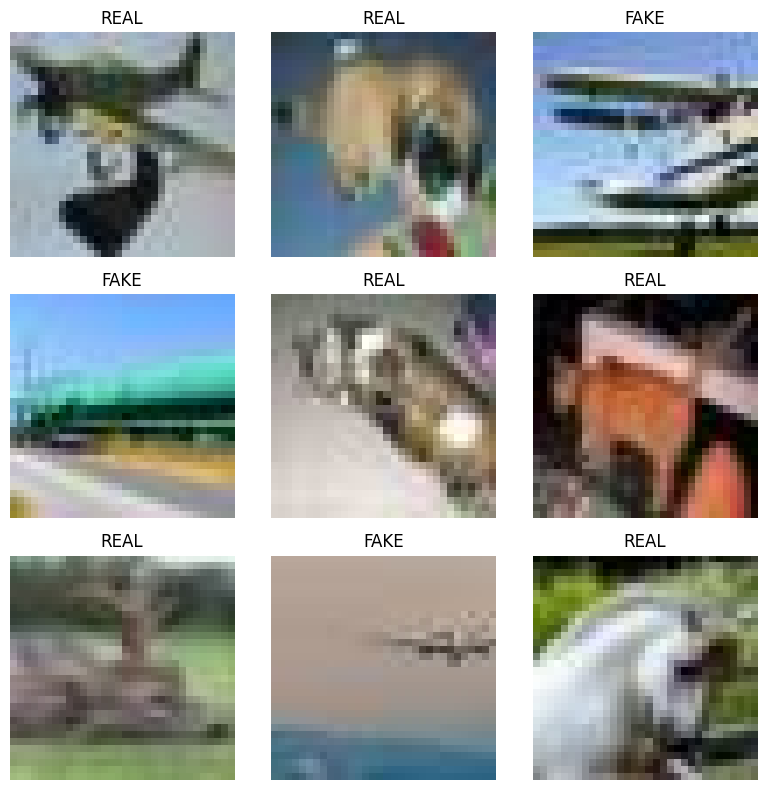

In [5]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i][0])])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Preprocessing, validation split, and augmentation


In [6]:
normalization_layer = layers.Rescaling(1.0 / 255)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

# Split off 10% of the training batches for validation, before augmenting,
# so validation always sees clean, unaltered images.
n_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = max(1, n_batches // 10)

raw_val_ds = train_ds.take(val_batches)
raw_train_ds = train_ds.skip(val_batches)

train_ds_final = prepare(raw_train_ds, augment=True, shuffle=True)
val_ds_final = prepare(raw_val_ds)
test_ds_final = prepare(test_ds)

## 3. Baseline CNN

In [7]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(16, (3, 3), padding='same', strides=2, activation='relu'),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,105 (410.57 KB)

 Trainable params: 105,105 (410.57 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_history = baseline_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=12,
)

Epoch 1/12


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8042 - loss: 0.4173 - val_accuracy: 0.8220 - val_loss: 0.3897
Epoch 2/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8610 - loss: 0.3216 - val_accuracy: 0.7991 - val_loss: 0.4801
Epoch 3/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8762 - loss: 0.2901 - val_accuracy: 0.8432 - val_loss: 0.3912
Epoch 4/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8852 - loss: 0.2711 - val_accuracy: 0.8144 - val_loss: 0.4761
Epoch 5/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8919 - loss: 0.2585 - val_accuracy: 0.8559 - val_loss: 0.3477
Epoch 6/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8984 - loss: 0.2471 - val_accuracy: 0.8320 - val_loss: 0.4463
Epoch 7/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9023 - loss: 0.2360 - val_accuracy: 0.8364 - val_loss: 0.3959
Epoch 8/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9060 - loss: 0.2298 - val

### Baseline result: diagnosing overfitting


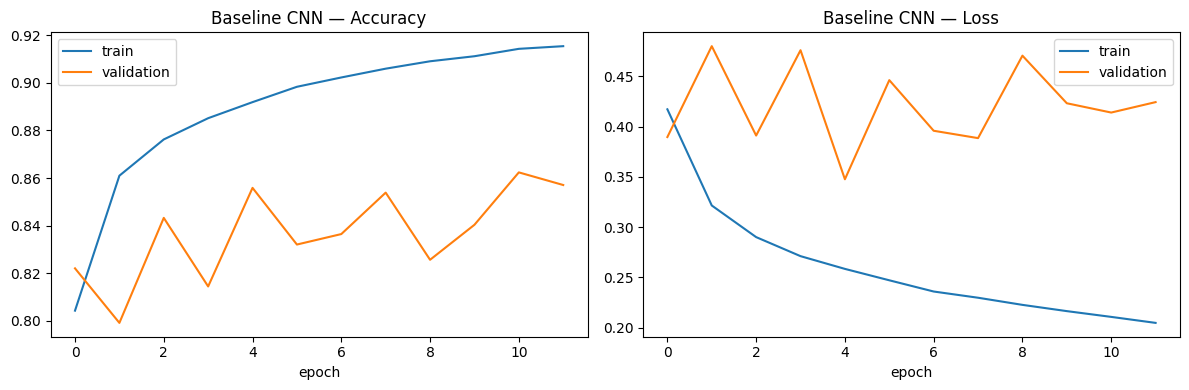

In [9]:
def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_curves(baseline_history, 'Baseline CNN')

## 4. Improved CNN

In [10]:
from tensorflow.keras import regularizers

def build_improved_cnn():
    reg = regularizers.l2(1e-4)

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(16, (3, 3), padding='same', strides=2, activation='relu', kernel_regularizer=reg),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

improved_model = build_improved_cnn()
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,105 (410.57 KB)

 Trainable params: 105,105 (410.57 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

improved_history = improved_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20,          # allow more epochs; EarlyStopping decides when to actually stop
    callbacks=[early_stop],
)

Epoch 1/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7763 - loss: 0.4830 - val_accuracy: 0.8184 - val_loss: 0.4088
Epoch 2/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8463 - loss: 0.3747 - val_accuracy: 0.8326 - val_loss: 0.3995
Epoch 3/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8655 - loss: 0.3410 - val_accuracy: 0.8445 - val_loss: 0.3747
Epoch 4/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8748 - loss: 0.3244 - val_accuracy: 0.8542 - val_loss: 0.3609
Epoch 5/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8798 - loss: 0.3146 - val_accuracy: 0.8639 - val_loss: 0.3555
Epoch 6/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8823 - loss: 0.3076 - val_accuracy: 0.8658 - val_loss: 0.3378
Epoch 7/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8856 - loss: 0.3008 - val_accuracy: 0.8735 - val_loss: 0.3306
Epoch 8/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8898 - loss: 0

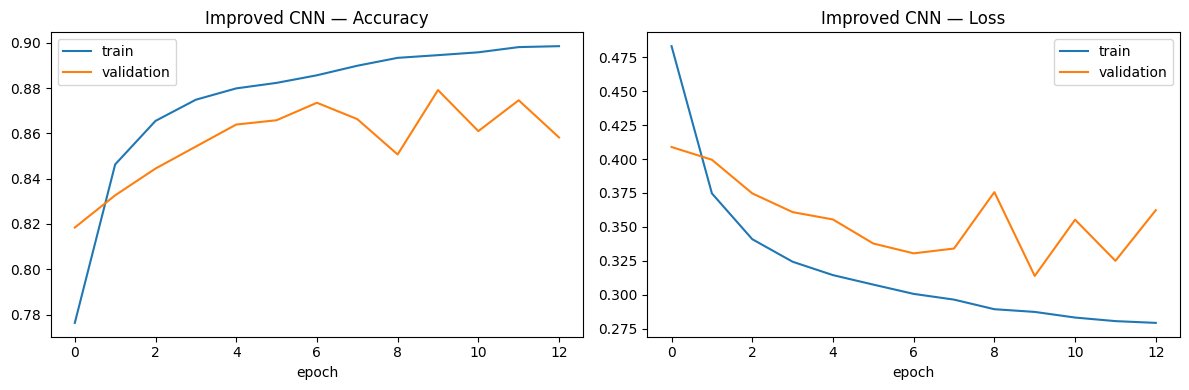

In [12]:
plot_curves(improved_history, 'Improved CNN')

## 5. Ablation: is augmentation the reason accuracy is lower than the baseline?

Epoch 1/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8320 - loss: 0.3929 - val_accuracy: 0.8834 - val_loss: 0.2974
Epoch 2/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8950 - loss: 0.2813 - val_accuracy: 0.9060 - val_loss: 0.2469
Epoch 3/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9085 - loss: 0.2545 - val_accuracy: 0.9179 - val_loss: 0.2275
Epoch 4/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9143 - loss: 0.2414 - val_accuracy: 0.9181 - val_loss: 0.2327
Epoch 5/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9187 - loss: 0.2327 - val_accuracy: 0.9211 - val_loss: 0.2221
Epoch 6/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9216 - loss: 0.2259 - val_accuracy: 0.9245 - val_loss: 0.2151
Epoch 7/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9245 - loss: 0.2219 - val_accuracy: 0.9150 - val_loss: 0.2363
Epoch 8/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9264 - loss: 0

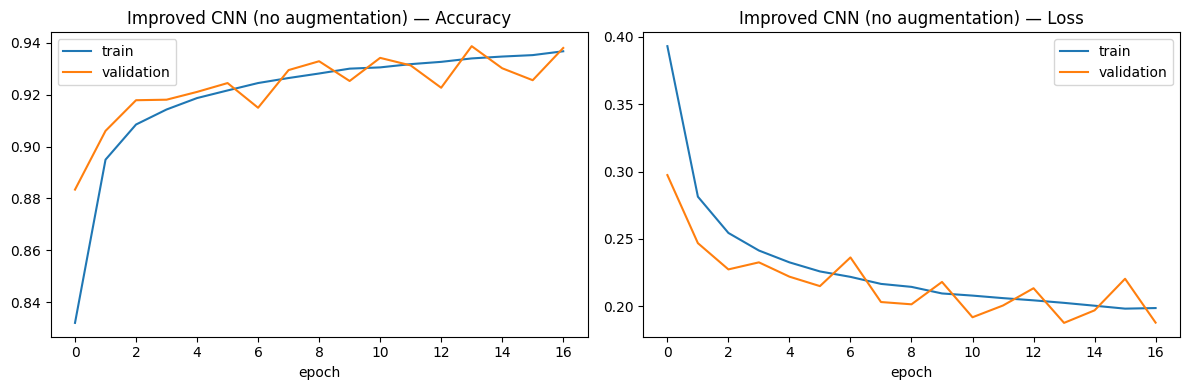

In [13]:
train_ds_no_aug = prepare(raw_train_ds, augment=False, shuffle=True)

no_aug_model = build_improved_cnn()
no_aug_history = no_aug_model.fit(
    train_ds_no_aug,
    validation_data=val_ds_final,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
)

plot_curves(no_aug_history, 'Improved CNN (no augmentation)')

## 6. Evaluation on the test set


 93/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-09-01 01:58:49.710768: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Baseline CNN (overfit) ===
              precision    recall  f1-score   support

        FAKE       0.79      0.98      0.88     10000
        REAL       0.98      0.74      0.84     10000

    accuracy                           0.86     20000
   macro avg       0.89      0.86      0.86     20000
weighted avg       0.89      0.86      0.86     20000



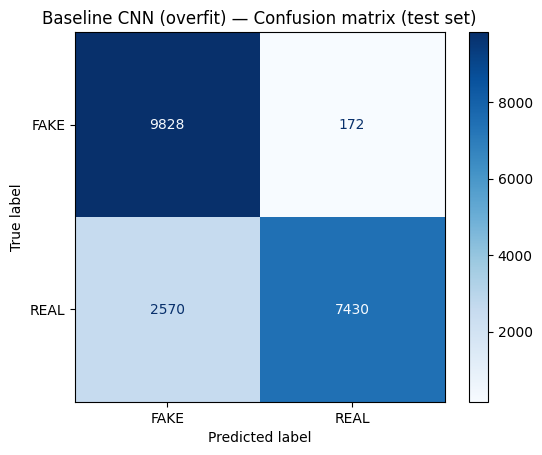

 93/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-09-01 01:58:50.967490: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Improved CNN (regularized + augmented) ===
              precision    recall  f1-score   support

        FAKE       0.83      0.97      0.89     10000
        REAL       0.96      0.80      0.87     10000

    accuracy                           0.88     20000
   macro avg       0.89      0.88      0.88     20000
weighted avg       0.89      0.88      0.88     20000



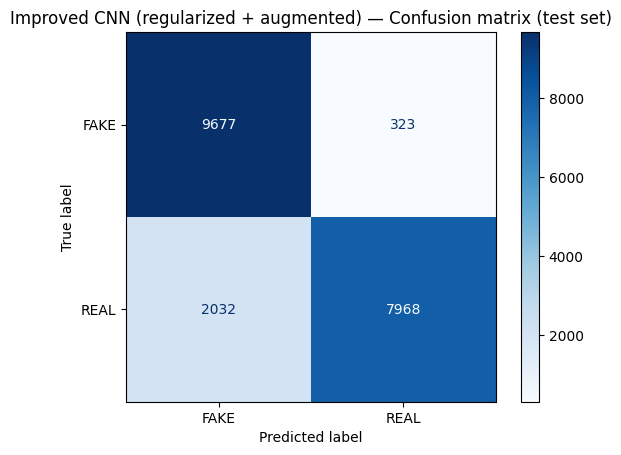

 92/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-09-01 01:58:52.149973: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Improved CNN (regularized, no augmentation) ===
              precision    recall  f1-score   support

        FAKE       0.93      0.95      0.94     10000
        REAL       0.95      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



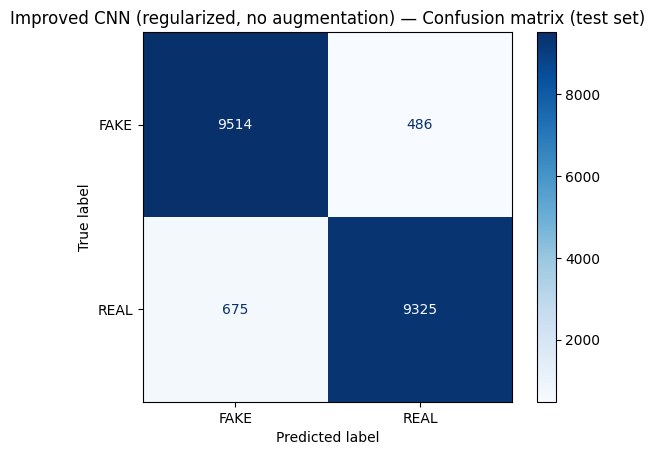

In [14]:
def evaluate_model(model, name):
    y_true = np.concatenate([y.numpy() for _, y in test_ds_final], axis=0).astype(int).ravel()
    y_prob = model.predict(test_ds_final).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion matrix (test set)')
    plt.show()

    return y_true, y_prob, y_pred

baseline_results = evaluate_model(baseline_model, 'Baseline CNN (overfit)')
improved_results = evaluate_model(improved_model, 'Improved CNN (regularized + augmented)')
no_aug_results = evaluate_model(no_aug_model, 'Improved CNN (regularized, no augmentation)')

### ROC curve and AUC

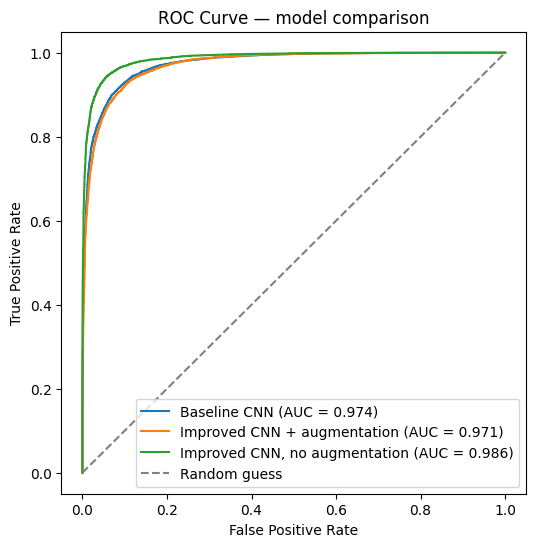

In [15]:
plt.figure(figsize=(6, 6))
for (y_true, y_prob, _), name in [
    (baseline_results, 'Baseline CNN'),
    (improved_results, 'Improved CNN + augmentation'),
    (no_aug_results, 'Improved CNN, no augmentation'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — model comparison')
plt.legend()
plt.show()

### Side-by-side summary

In [16]:
for (y_true, y_prob, y_pred), name in [
    (baseline_results, 'Baseline CNN (overfit)'),
    (improved_results, 'Improved CNN (regularized + augmented)'),
    (no_aug_results, 'Improved CNN (regularized, no augmentation)'),
]:
    acc = (y_true == y_pred).mean()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f'{name:42s}  accuracy={acc:.4f}  AUC={roc_auc:.4f}')

Baseline CNN (overfit)                      accuracy=0.8629  AUC=0.9739
Improved CNN (regularized + augmented)      accuracy=0.8822  AUC=0.9713
Improved CNN (regularized, no augmentation)  accuracy=0.9419  AUC=0.9862


## 7. Error analysis

In [17]:
def collect_misclassified(model, ds, class_names, max_examples=9):
    real_as_fake = []
    fake_as_real = []
    for images, labels in ds:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        labels_np = labels.numpy().astype(int).ravel()
        for img, true_label, pred_label, prob in zip(images.numpy(), labels_np, preds, probs):
            if true_label == 1 and pred_label == 0 and len(real_as_fake) < max_examples:
                real_as_fake.append((img, prob))
            elif true_label == 0 and pred_label == 1 and len(fake_as_real) < max_examples:
                fake_as_real.append((img, prob))
        if len(real_as_fake) >= max_examples and len(fake_as_real) >= max_examples:
            break
    return real_as_fake, fake_as_real

real_as_fake, fake_as_real = collect_misclassified(improved_model, test_ds_final, class_names)

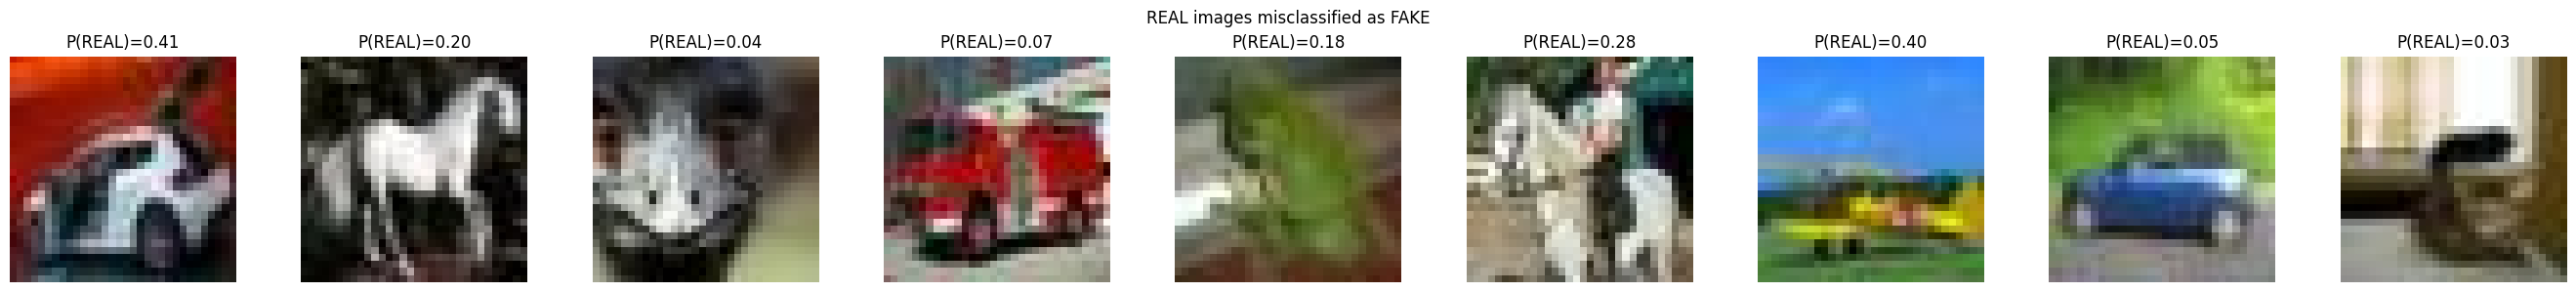

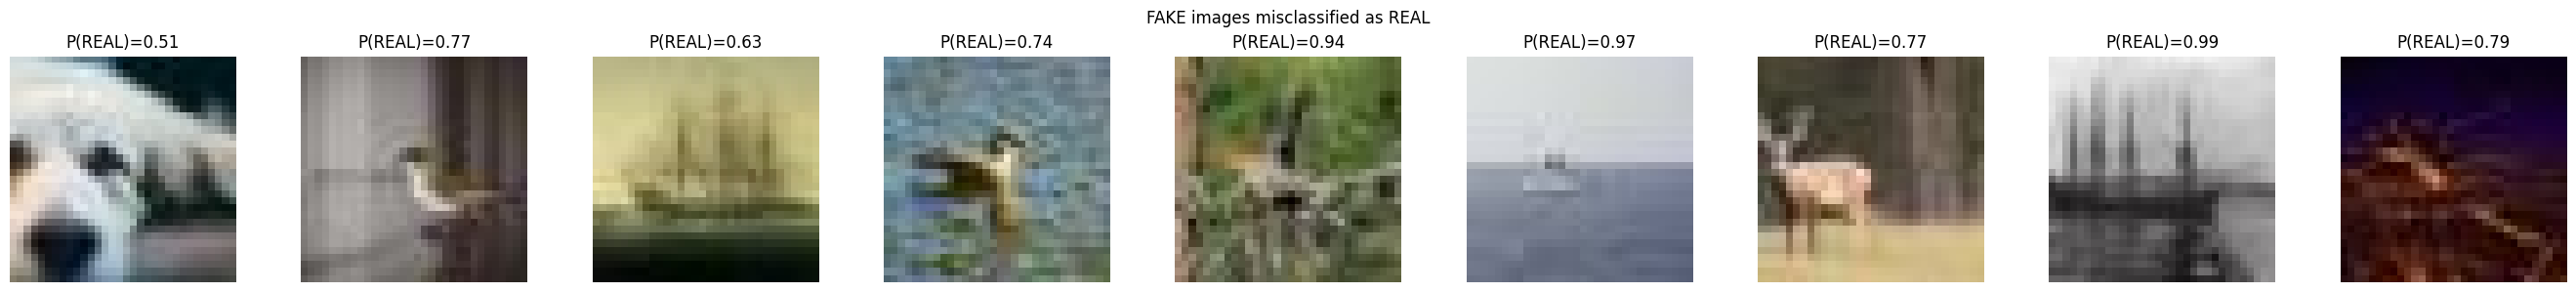

In [18]:
def plot_misclassified(examples, title):
    n = len(examples)
    if n == 0:
        print(f'No examples found for: {title}')
        return
    plt.figure(figsize=(3 * n, 3))
    for i, (img, prob) in enumerate(examples):
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f'P(REAL)={prob:.2f}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_misclassified(real_as_fake, 'REAL images misclassified as FAKE')
plot_misclassified(fake_as_real, 'FAKE images misclassified as REAL')

## 8. Save the best model

In [19]:
no_aug_model.save('Model.h5')